In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('q2_customers.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("\nScaled data sample:")
X_scaled_df.head()

Shape: (500, 6)

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Scaled data sample:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


## Task 1 — Why Scaling is Essential for K-Means

K-Means calculates distance (Euclidean) between data points to assign clusters.
If features are on different scales — e.g., `annual_spend` ranges in thousands while
`visits_per_month` is single-digit — the high-magnitude feature will dominate the
distance calculation and make other features irrelevant.

StandardScaler transforms all features to have mean=0 and std=1, ensuring every
feature contributes equally to the clustering.

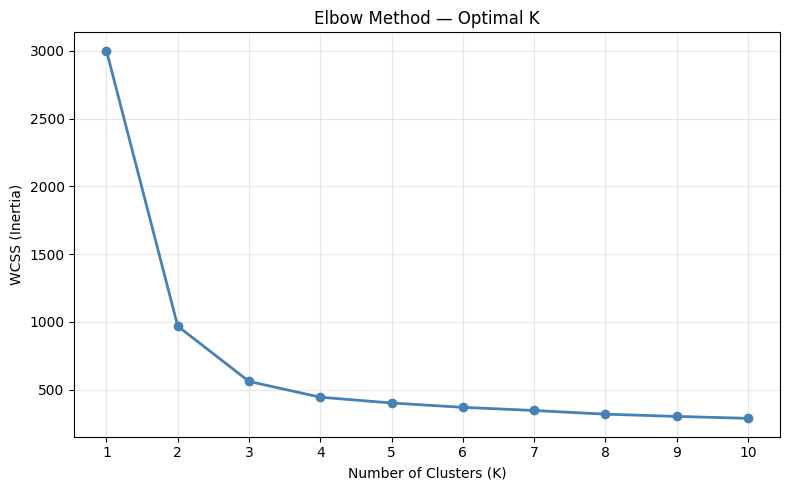

In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=100)
plt.show()

## Task 2 — Choosing K

From the elbow plot, the WCSS drops sharply from K=1 to K=3/4, then flattens out.
The "elbow" (point of diminishing returns) appears at **K=4**.
Beyond K=4, adding more clusters gives minimal reduction in WCSS but increases model complexity.
Therefore, **K=4** is selected as the optimal number of clusters.

In [ ]:
OPTIMAL_K = 4  # Change if your elbow shows a different value

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print centroids (back-transformed to original scale for interpretability)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
print("Cluster Centroids (original scale):\n")
display(centroids_df.round(2))

print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster Centroids (original scale):



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54



Cluster sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


## Task 3 — Cluster Interpretation (Business Terms)

Based on centroid values (adjust descriptions after running your output):

- **Cluster 0 — High-Value Loyalists**: High annual spend, large basket size, frequent visits. Prime candidates for loyalty rewards.
- **Cluster 1 — Young Infrequent Shoppers**: Low spend, fewer categories purchased, high days since last visit. Need re-engagement campaigns.
- **Cluster 2 — Frequent Low-Spenders**: High visits per month but small basket size. Upsell opportunity — bundle promotions could increase basket value.
- **Cluster 3 — Occasional Big-Spenders**: Low visit frequency but high basket size when they do visit. Seasonal promotions would suit them.

*(Adjust these descriptions based on your actual centroid output.)*

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("\nFeature Loadings:\n")
display(loadings_df.round(4))

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 89.13%

Feature Loadings:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405


## Task 4 — PCA Interpretation

**PC1** explains the most variance. Based on loadings, features with large absolute values
on PC1 are the primary drivers — likely `annual_spend` and `basket_size` (spending power axis).

**PC2** captures the next most variance and is driven by features with low PC1 loading but
high PC2 loading — likely `visits_per_month` and `days_since_last_visit` (engagement/recency axis).

Together, PC1 and PC2 capture the majority of the dataset's variance in just 2 dimensions,
enabling effective 2D visualisation.

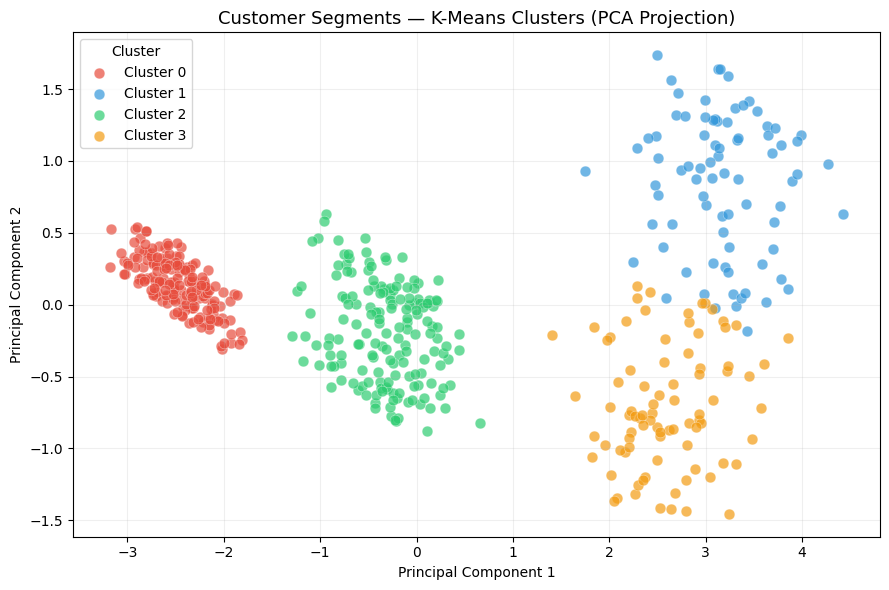

In [ ]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(9, 6))
for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id], label=f'Cluster {cluster_id}',
        alpha=0.7, s=60, edgecolors='white', linewidth=0.3
    )

plt.title('Customer Segments — K-Means Clusters (PCA Projection)', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_pca_plot.png', dpi=100)
plt.show()